# Experiment 1: full case corpus

One DAMICORE object represents one eligible category, while each document preserves
the canonical contextual combinations observed in all distinct `source_hash + category`
cases. Category prevalence is retained.


In [5]:
from pathlib import Path
import os
import sys

import pandas as pd
from IPython.display import SVG, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository or one of its subdirectories.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from hypotheses.violence_against_women.scripts.experiment_common import (
    artifact_paths,
    case_execution,
    category_order_from_manifest,
    ensure_artifact_directories,
    load_artifact_manifest,
    load_category_map,
    run_damicore_experiment,
    write_common_result_artifacts,
)

CATEGORY_SET_VERSION = os.getenv("DAMICORE_CATEGORY_SET_VERSION", "v2_30")
PATHS = artifact_paths(CATEGORY_SET_VERSION)
COMMON_WORK_ROOT = PATHS.common
NORMALIZED_WORK_ROOT = PATHS.normalized
CASE_FULL_WORK_ROOT = PATHS.case_full
CASE_BALANCED_WORK_ROOT = PATHS.case_balanced
RESULTS_ROOT = PATHS.results
ensure_artifact_directories(PATHS)
manifest = load_artifact_manifest(
    COMMON_WORK_ROOT / "artifact-manifest.json",
    category_set_version=CATEGORY_SET_VERSION,
)
category_order = category_order_from_manifest(manifest)
category_map = load_category_map(COMMON_WORK_ROOT / "category-map.csv")
category_support = pd.read_csv(COMMON_WORK_ROOT / "category-support.csv")
assert category_map["category"].tolist() == category_order
assert set(category_support["category"]) == set(category_order)
assert manifest["dimension_count"] == 20


## Run DAMICORE and record the common result contract


distance: 100%|██████████| 435/435 [04:16<00:00,  1.70pair/s]


,experiment,object_id,label,category,cluster
29,case_full,file_000030,category-030.txt,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,3
11,case_full,file_000012,category-012.txt,INTEGRIDADE > FÍSICA > AGRESSÃO ou VIAS DE FATO,5
12,case_full,file_000013,category-013.txt,INTEGRIDADE > FÍSICA > LESÃO CORPORAL,6
13,case_full,file_000014,category-014.txt,INTEGRIDADE > FÍSICA > MAUS TRATOS,6
14,case_full,file_000015,category-015.txt,INTEGRIDADE > FÍSICA > TORTURA FÍSICA,0
15,case_full,file_000016,category-016.txt,INTEGRIDADE > FÍSICA > VIOLÊNCIA OBSTÉTRICA,3
22,case_full,file_000023,category-023.txt,INTEGRIDADE > PATRIMONIAL > INDIVIDUAL,5
19,case_full,file_000020,category-020.txt,INTEGRIDADE > PSÍQUICA > ALIENAÇÃO PARENTAL,7
16,case_full,file_000017,category-017.txt,INTEGRIDADE > PSÍQUICA > AMEAÇA ou COAÇÃO,6
17,case_full,file_000018,category-018.txt,INTEGRIDADE > PSÍQUICA > ASSÉDIO MORAL,7


,LIBERDADE > SEXUAL > FÍSICA > ESTUPRO,LIBERDADE > SEXUAL > ESTUPRO DE VULNERÁVEL,LIBERDADE > SEXUAL > ESTUPRO DE VULNERÁVEL > PEDOFILIA,LIBERDADE > SEXUAL > ESTUPRO VIRTUAL,LIBERDADE > SEXUAL > ESTUPRO CORRETIVO,LIBERDADE > SEXUAL > FÍSICA > ABUSO SEXUAL FÍSICO,LIBERDADE > SEXUAL > FÍSICA > EXPLORAÇÃO SEXUAL,LIBERDADE > SEXUAL > IMPORTUNAÇÃO SEXUAL,LIBERDADE > SEXUAL > PSÍQUICA > ABUSO SEXUAL PSÍQUICO,LIBERDADE > SEXUAL > PSÍQUICA > ASSÉDIO SEXUAL,...,INTEGRIDADE > PSÍQUICA > CONSTRANGIMENTO,INTEGRIDADE > PSÍQUICA > EXPOSIÇÃO (EROTIZAÇÃO),INTEGRIDADE > PATRIMONIAL > INDIVIDUAL,LIBERDADE > DIREITOS INDIVIDUAIS > CÁRCERE PRIVADO,LIBERDADE > DIREITOS INDIVIDUAIS > SEQUESTRO,LIBERDADE > DIREITOS INDIVIDUAIS > STALKING,LIBERDADE > DIREITOS INDIVIDUAIS > TRÁFICO DE MULHERES - INTERNACIONAL,LIBERDADE > DIREITOS INDIVIDUAIS > TRÁFICO DE MULHERES - NACIONAL,VIDA > FEMINICÍDIO,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES
LIBERDADE > SEXUAL > FÍSICA > ESTUPRO,0.000,0.999,0.999,0.999,0.999,0.999,0.999,0.999,0.999,0.999,...,1.0,0.999,1.0,0.999,0.999,0.999,0.999,0.999,0.999,0.999
LIBERDADE > SEXUAL > ESTUPRO DE VULNERÁVEL,0.999,0.000,0.999,0.999,0.999,0.999,0.999,0.999,0.999,0.999,...,1.0,0.999,1.0,0.999,0.999,0.999,0.999,0.999,0.999,0.999
LIBERDADE > SEXUAL > ESTUPRO DE VULNERÁVEL > PEDOFILIA,0.999,0.999,0.000,0.996,0.996,0.998,0.998,0.998,0.999,0.999,...,1.0,0.999,1.0,0.999,0.996,0.997,0.997,0.997,0.997,0.997
LIBERDADE > SEXUAL > ESTUPRO VIRTUAL,0.999,0.999,0.996,0.000,0.981,0.998,0.997,0.998,0.999,0.999,...,1.0,0.999,1.0,0.999,0.982,0.992,0.983,0.982,0.983,0.981
LIBERDADE > SEXUAL > ESTUPRO CORRETIVO,0.999,0.999,0.996,0.981,0.000,0.999,0.998,0.998,0.999,0.999,...,1.0,0.999,1.0,0.999,0.980,0.992,0.915,0.909,0.916,0.906
LIBERDADE > SEXUAL > FÍSICA > ABUSO SEXUAL FÍSICO,0.999,0.999,0.998,0.998,0.999,0.000,0.999,0.999,0.999,0.999,...,1.0,0.999,1.0,0.999,0.999,0.998,0.998,0.998,0.998,0.998
LIBERDADE > SEXUAL > FÍSICA > EXPLORAÇÃO SEXUAL,0.999,0.999,0.998,0.997,0.998,0.999,0.000,0.998,0.999,0.999,...,1.0,0.999,1.0,0.999,0.998,0.998,0.998,0.998,0.998,0.998
LIBERDADE > SEXUAL > IMPORTUNAÇÃO SEXUAL,0.999,0.999,0.998,0.998,0.998,0.999,0.998,0.000,0.999,0.999,...,1.0,0.999,1.0,0.999,0.998,0.998,0.998,0.998,0.998,0.998
LIBERDADE > SEXUAL > PSÍQUICA > ABUSO SEXUAL PSÍQUICO,0.999,0.999,0.999,0.999,0.999,0.999,0.999,0.999,0.000,0.999,...,1.0,0.999,1.0,0.999,0.999,0.999,0.999,0.999,0.999,0.999
LIBERDADE > SEXUAL > PSÍQUICA > ASSÉDIO SEXUAL,0.999,0.999,0.999,0.999,0.999,0.999,0.999,0.999,0.999,0.000,...,1.0,0.999,1.0,0.999,0.999,0.999,0.999,0.999,0.999,0.999


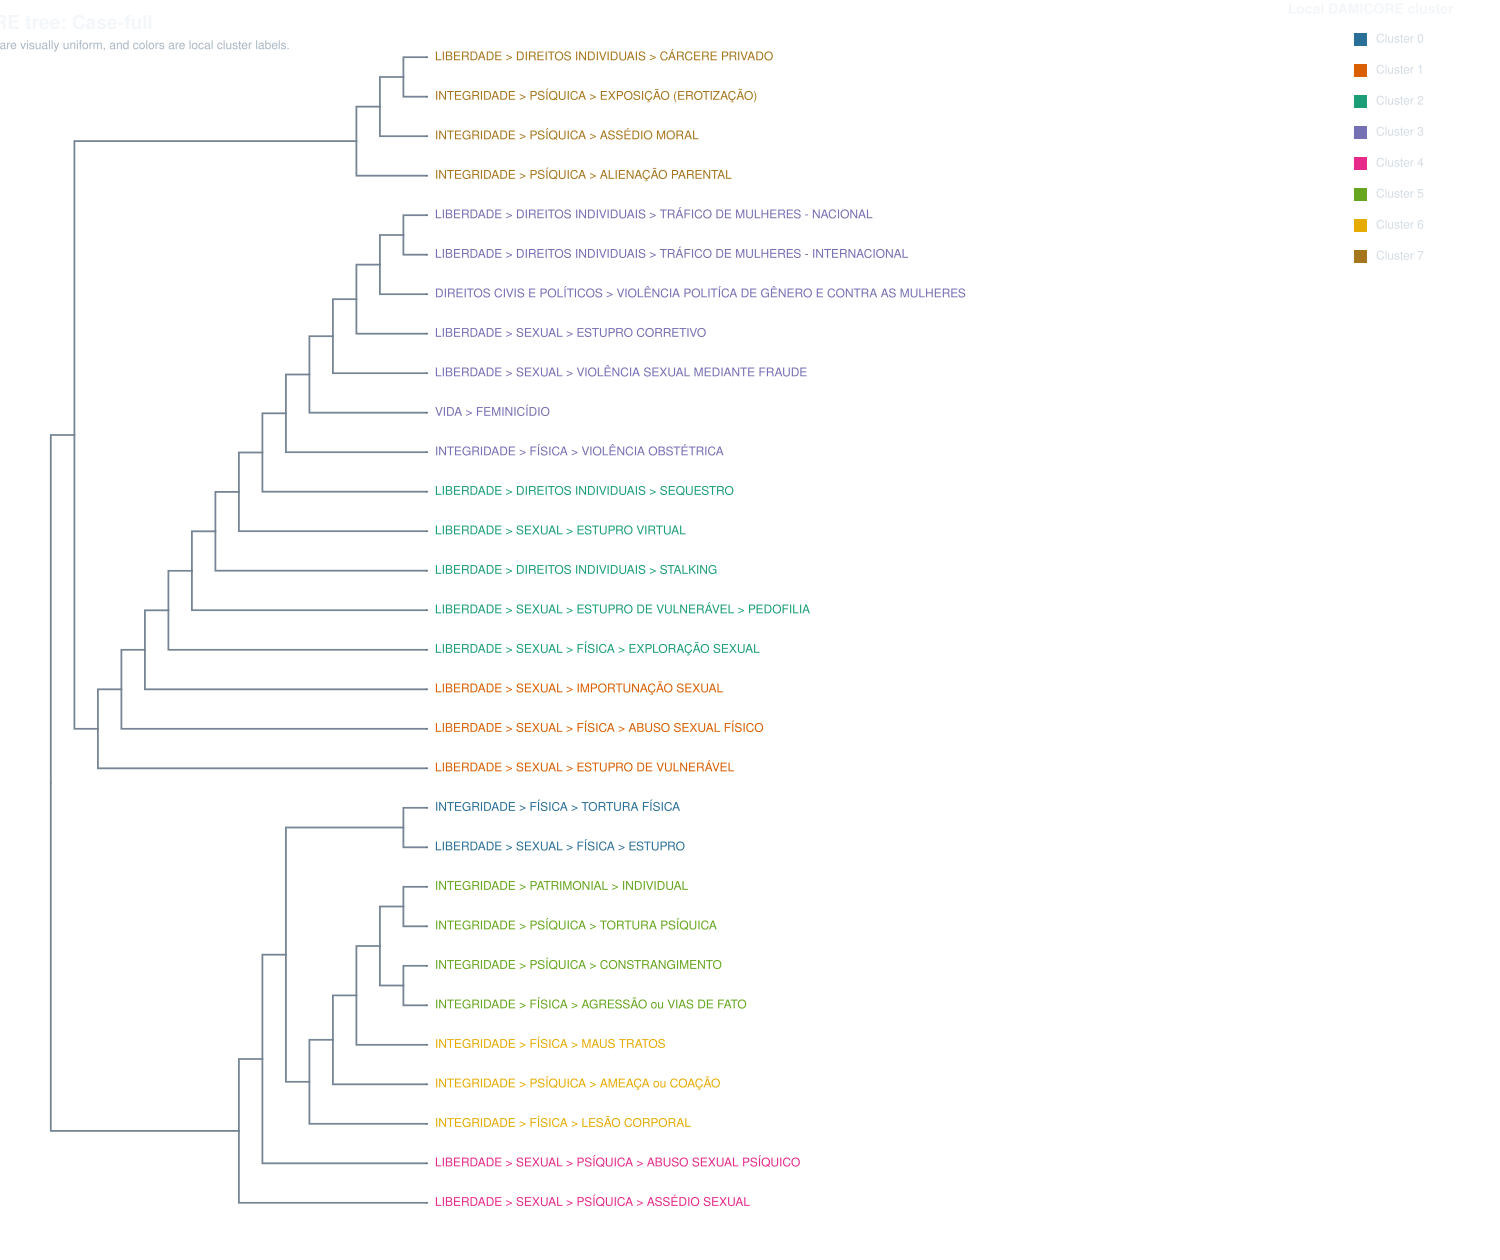

In [6]:
case_category_map = pd.read_csv(COMMON_WORK_ROOT / "case-category-map.csv")
case_full_support = (
    case_category_map.loc[case_category_map["regime"] == "case-full", ["category", "case_count"]]
    .rename(columns={"case_count": "support"})
    .set_index("category")
    .loc[category_order]
    .reset_index()
)
bytes_by_category = (
    case_category_map.loc[case_category_map["regime"] == "case-full"]
    .set_index("category")["bytes"]
    .astype(int)
    .to_dict()
)
assert case_full_support["category"].tolist() == category_order

result = run_damicore_experiment(
    experiment_name="case_full",
    corpus_dir=CASE_FULL_WORK_ROOT / "corpus",
    raw_runs_dir=CASE_FULL_WORK_ROOT / "runs",
    execution=case_execution(),
)
assert result["status"] == "completed", result["preview"]
case_full_result = write_common_result_artifacts(
    result=result,
    category_map=category_map,
    category_order=category_order,
    support=case_full_support,
    bytes_by_category=bytes_by_category,
    output_dir=RESULTS_ROOT / "case_full",
    support_column="support",
    support_label="Distinct cases (log scale)",
    title_prefix="Case-full",
    manifest=manifest,
)
display(case_full_result["membership_by_category"])
display(case_full_result["distance"].round(3))
display(SVG(filename=str(RESULTS_ROOT / "case_full" / "tree.svg")))


## Interpretation boundary

`case-full` combines contextual similarity with observed category prevalence and
corpus volume. It is not directly comparable to an equal-support regime without the
balanced experiment.
